In [1089]:
# Import necessary libraries and set up MySQL connection
import csv
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
from mysql.connector import Error
import os
from dotenv import load_dotenv  # Import dotenv

# Load environment variables from .env file
load_dotenv()

True

## Setup

In [1090]:
# Function to establish a database connection
def get_db_connection():
    try:
        connection = mysql.connector.connect(
            host='localhost',
            port=3306,
            database='games_db_benchmark',
            user='root',
            password=os.getenv('DB_PASSWORD')
        )
        if connection.is_connected():
            print("Connection to MySQL DB successful")
        return connection
    except Error as e:
        print(f"Error while connecting to MySQL: {e}")
        return None

In [1091]:
def setup_players():
    # Create tables and insert data
    connection = get_db_connection()
    if connection:
        cursor = connection.cursor()

        # Create the 'players' table
        cursor.execute("""
        CREATE TABLE IF NOT EXISTS players (
            id INT PRIMARY KEY,
            name VARCHAR(50),
            badge VARCHAR(20)
        )
        """)

        # Insert data into 'players'
        cursor.executemany(
            """
            INSERT INTO players (id, name, badge) VALUES (%s, %s, %s)
            """,
            [
                (1, 'Alice', 'gold'),
                (2, 'Bob', 'silver'),
                (3, 'Charlie', 'regular'),
                (4, 'Diana', 'regular'),
                (5, 'Eve', 'regular')
            ]
        )

        connection.commit()
        cursor.close()
        connection.close()

In [1092]:
# Generate 1000 rows of data
import random

def generate_data():
    data = []

    game_id = 1

    # Generate 30% rows for player_id=1
    for _ in range(300):  # Subtract 1 because we already added one row
        points = random.randint(-10, 10)
        data.append((1, game_id, points))
        game_id = game_id + 1

    # Generate the remaining rows for player_id=2 to 5
    while len(data) < 1000:
        player_id = random.randint(2, 5)
        points = random.randint(-10, 10)
        data.append((player_id, game_id, points))
        game_id = game_id + 1

    return data

In [1093]:
def setup_points_a(data):
    connection = get_db_connection()
    if connection:
        cursor = connection.cursor()

        # Create the `points_a` table
        cursor.execute("""
        CREATE TABLE IF NOT EXISTS points_a (
            game_id INT,
            player_id INT,
            points INT,
            id INT AUTO_INCREMENT PRIMARY KEY
        )
        """)

        # Insert data into `points_a`
        cursor.executemany(
            """
            INSERT INTO points_a (player_id, game_id, points) VALUES (%s, %s, %s)
            """,
            data
        )

        connection.commit()
        cursor.close()
        connection.close()

In [1094]:
def setup_points_b(data):
    connection = get_db_connection()
    if connection:
        cursor = connection.cursor()

        # Create the `points_b` table
        cursor.execute("""
        CREATE TABLE IF NOT EXISTS points_b (
            game_id INT,
            player_id INT,
            points INT,
            id INT AUTO_INCREMENT PRIMARY KEY,
            FOREIGN KEY (player_id) REFERENCES players(id)
        )
        """)

        # Insert data into `points_b`
        cursor.executemany(
            """
            INSERT INTO points_b (player_id, game_id, points) VALUES (%s, %s, %s)
            """,
            data
        )

        connection.commit()
        cursor.close()
        connection.close()

In [1095]:
def setup_points_c(data):
    connection = get_db_connection()
    if connection:
        cursor = connection.cursor()

        # Create the `points_c` table
        cursor.execute("""
        CREATE TABLE IF NOT EXISTS points_c (
            game_id INT,
            player_id INT,
            points INT,
            PRIMARY KEY (player_id, game_id),
            FOREIGN KEY (player_id) REFERENCES players(id)
        )
        """)

        # Insert data into `points_c`
        cursor.executemany(
            """
            INSERT INTO points_c (player_id, game_id, points) VALUES (%s, %s, %s)
            """,
            data
        )

        connection.commit()
        cursor.close()
        connection.close()

In [1096]:
# setup_players()
# data = generate_data()
# setup_points_a(data)
# setup_points_b(data)
# setup_points_c(data)

## Benchmark

In [1097]:
import time
# change to use profiling from mysql

In [1098]:
# Function to execute the query and measure execution time
def execute_query_with_profiling(connection, table_name):
    cursor = connection.cursor()
    start_time = time.time()
    cursor.execute("START TRANSACTION;")
    cursor.execute(f"SELECT SQL_NO_CACHE * FROM {table_name} WHERE game_id = 1 AND player_id = 1 FOR UPDATE;")
    # Fetch all rows to ensure the result is fully consumed
    cursor.fetchall()
    cursor.execute("COMMIT;")
    end_time = time.time()
    execution_time = end_time - start_time
    cursor.close()
    return execution_time

In [1099]:
# Function to run the query multiple times and calculate average time
def run_query_multiple_times(isolation_level, table_name, iterations=10):
    connection = get_db_connection()
    if not connection:
        return None
    cursor = connection.cursor()
    cursor.execute(f"SET SESSION TRANSACTION ISOLATION LEVEL {isolation_level}")
    print(f"Connection established with isolation level: {isolation_level}")
    
    execution_times = []
    for _ in range(iterations):
        execution_time = execute_query_with_profiling(connection, table_name)
        execution_times.append(execution_time)
    connection.close()

    # save list to unique named file
    filename = f"execution_times_{isolation_level}_{table_name}.csv"
    with open(filename, 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['execution_time'])
        for time in execution_times:
            writer.writerow([time])
    
    average_time = sum(execution_times) / len(execution_times)
    return average_time

In [1100]:
# Function to run the experiment for all tables and isolation levels
def run_experiment():
    tables = ['points_a', 'points_b', 'points_c']
    isolation_levels = ['REPEATABLE READ', 'READ COMMITTED']
    results = []
    for isolation_level in isolation_levels:
        for table in tables:
            avg_time = run_query_multiple_times(isolation_level, table)
            results.append({'table': table, 'isolation_level': isolation_level, 'average_time': avg_time})
    return results

In [1101]:
# Function to save results to CSV
def save_results_to_csv(results, filename):
    df = pd.DataFrame(results)
    df.to_csv(filename, index=False)
    print(f"Results saved to {filename}")

# Function to load results from CSV
def load_results_from_csv(filename):
    df = pd.read_csv(filename)
    return df.to_dict('records')

In [1102]:
# Function to plot the results
def plot_results(results):
    df = pd.DataFrame(results)
    plt.figure(figsize=(10, 6))

    # Rename x-axis values
    table_mapping = {
        'points_a': 'points_1a',
        'points_b': 'points_1b',
        'points_c': 'points_1c'
    }
    df['table'] = df['table'].map(table_mapping)

    for isolation_level in df['isolation_level'].unique():
        subset = df[df['isolation_level'] == isolation_level]
        plt.plot(subset['table'], subset['average_time'] * 1000, marker='o', label=isolation_level)

    plt.xlabel('Points Table')
    plt.ylabel('Average Time (ms)')
    plt.title('Query Performance by Isolation Level')
    plt.legend()
    plt.grid(True)
    plt.savefig('query_performance.png', dpi = 300)
    plt.show()

In [1103]:
# Run the experiment and visualize results
# results = run_experiment()
# save_results_to_csv(results, 'query_performance.csv')

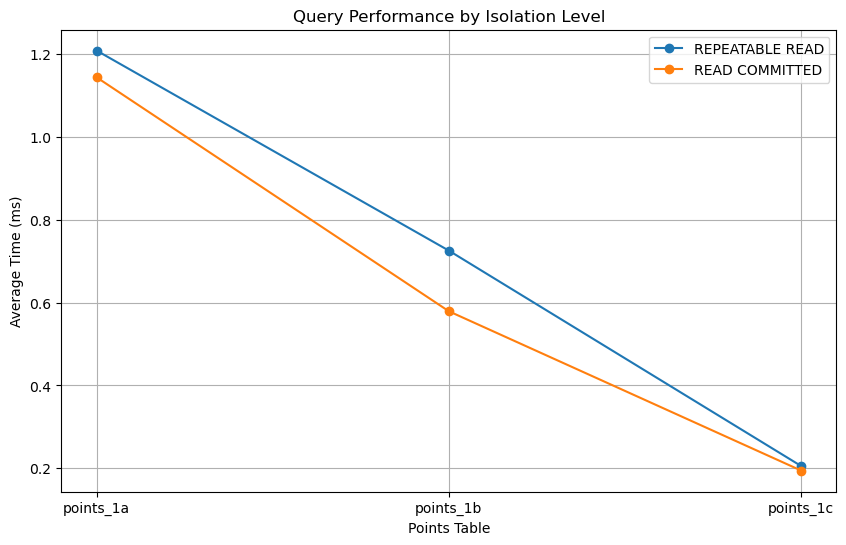

In [1104]:
results = load_results_from_csv('query_performance.csv')
plot_results(results)